# Exercise - Digitization and Data Analytics - Machine Learning

Exercise - Digitization and Data Analytics - Machine Learning

In [1]:
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn

/Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1/DDA/.venv/bin/pip: line 2: /Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1 Sub/DDA/.venv/bin/python: No such file or directory
/Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1/DDA/.venv/bin/pip: line 2: exec: /Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1 Sub/DDA/.venv/bin/python: cannot execute: No such file or directory
/Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1/DDA/.venv/bin/pip: line 2: /Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1 Sub/DDA/.venv/bin/python: No such file or directory
/Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1/DDA/.venv/bin/pip: line 2: exec: /Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1 Sub/DDA/.venv/bin/python: cannot execute: No such file or directory
/Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1/DDA/.venv/bin/pip: line 2: /Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1 Sub/DDA/.venv/bin/pytho

In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing, fetch_covtype
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, r2_score, mean_squared_error
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [3]:
# Load Datasets
california = fetch_california_housing()
cover_type = fetch_covtype()

# Preparing the Dataset with Numerical Target variable (Regression)
reg_data_without_target = pd.DataFrame(california.data, columns=california.feature_names)
reg_target = pd.DataFrame(california.target, columns=['House_Value'])

# Preparing the Dataset with Categorical Target variable (Classification)
cla_data_without_target = pd.DataFrame(cover_type.data, columns=cover_type.feature_names)
cla_target = pd.DataFrame(cover_type.target, columns=['Cover_Type'])

## Task 1 - Correlation Matrices

### Compute the correlation matrices for the datasets and plot it to visualize the results.

**What is it?** A correlation matrix is a table that shows how strongly different variables are linked to one another. 

**Why are we doing this?** We want to see if some of our columns are basically giving us the exact same information (overlapping). If they overlap too much, it means we can safely compress our dataset in the next steps.

### Observing the the plots, what variables are strongly correlated?

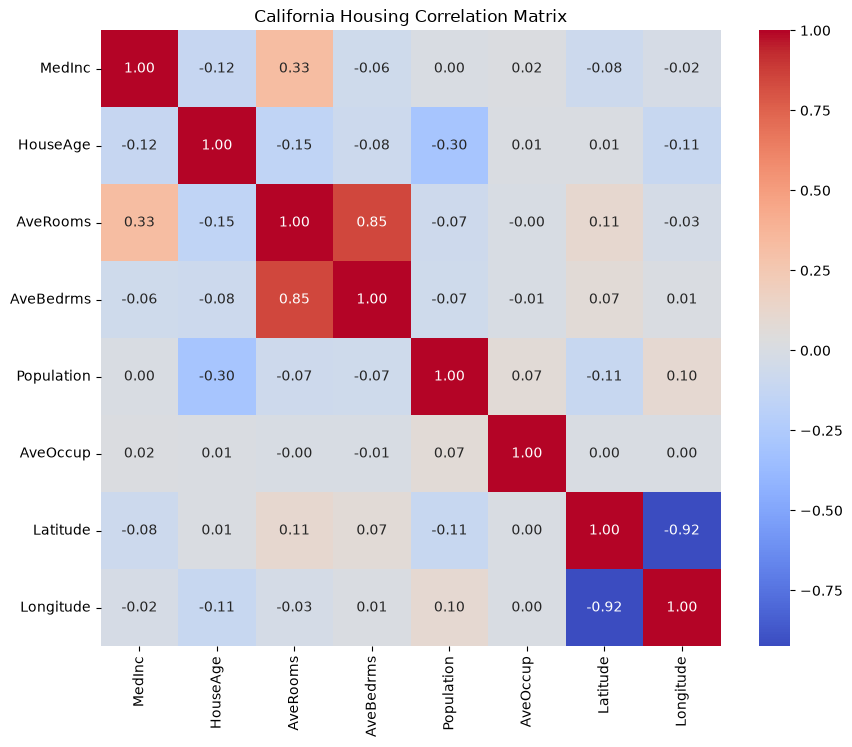

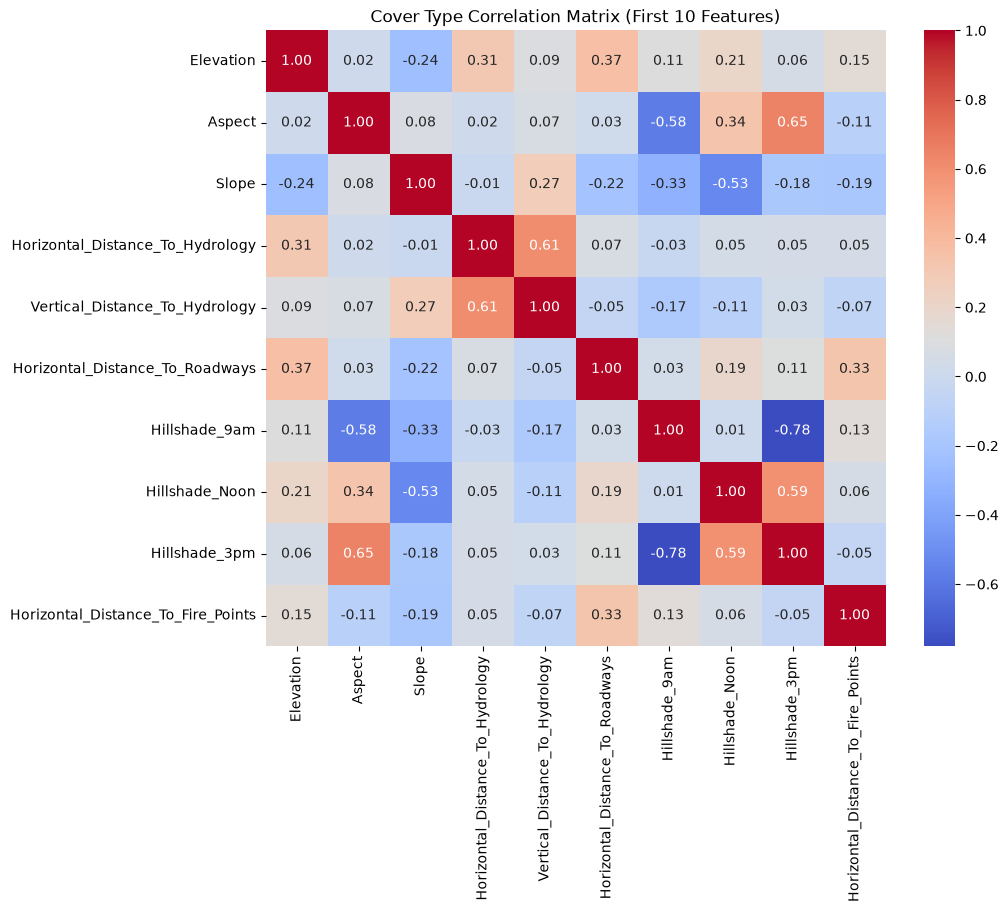

In [4]:
# California Housing Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(reg_data_without_target.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("California Housing Correlation Matrix")
plt.show()

# Cover Type Correlation Matrix (Showing the first 10 continuous features for readability)
plt.figure(figsize=(10, 8))
sns.heatmap(cla_data_without_target.iloc[:, :10].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cover Type Correlation Matrix (First 10 Features)")
plt.show()

**What do these results tell us?**

1. **California Housing:** If you look at the heatmap, you will see a very high score (close to 1.0) between `AveRooms` and `AveBedrms`. This makes logical sense: neighborhoods with more rooms generally have more bedrooms. 
   
2. **Cover Type:** In the forest dataset, you will notice strong relationships between features like the horizontal and vertical distances to water (hydrology).

**The Main Takeaway:**
Seeing these high correlation numbers proves that our datasets contain overlapping, redundant information (this is called **multicollinearity**). Because these columns are essentially telling the model the exact same story, we can safely compress them. This perfectly sets up our next step (Task 2: PCA), where we will mathematically shrink these overlapping columns into fewer, smarter variables!

## Task 2 - Principle Component Analysis (PCA)


**What is it?** PCA is a linear mathematical transformation that squishes our data down into fewer, non-correlated columns (components) while trying to keep the original variance (information) intact.

**Why are we doing this?** To remove noise, solve the multicollinearity issue we found in Task 1, and make our downstream models run faster.

### Apply PCA (Principle Component Analysis) to the datasets.

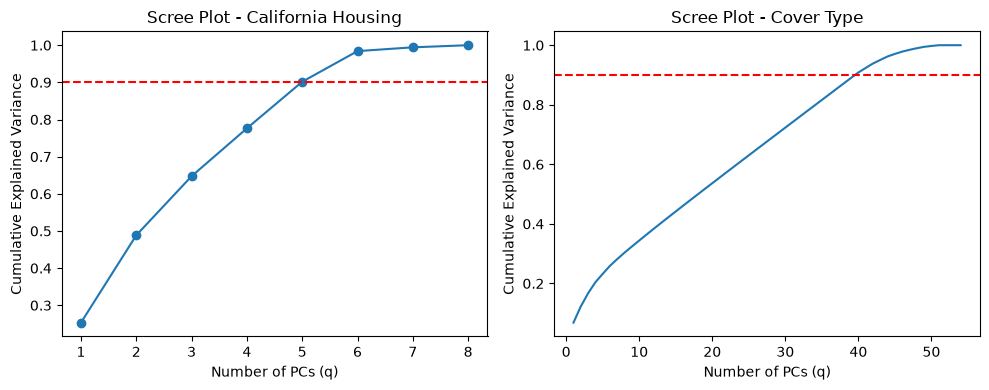

In [5]:
# CRITICAL: PCA is highly sensitive to the scale of the data. 
# We MUST standardize the data (mean = 0, variance = 1) before applying PCA.
scaler_reg = StandardScaler()
reg_data_scaled = scaler_reg.fit_transform(reg_data_without_target)

# Initialize and fit PCA on the scaled regression data
pca_reg = PCA()
pca_reg.fit(reg_data_scaled)

# Repeat the scaling and PCA fitting for the classification data
scaler_cla = StandardScaler()
cla_data_scaled = scaler_cla.fit_transform(cla_data_without_target)

pca_cla = PCA()
pca_cla.fit(cla_data_scaled)

# Plotting the Scree Plots to visualize explained variance
plt.figure(figsize=(10, 4))

# Scree plot for California Housing
plt.subplot(1, 2, 1)
# np.cumsum calculates the cumulative sum of the variance explained by each consecutive component
plt.plot(range(1, len(pca_reg.explained_variance_ratio_) + 1), np.cumsum(pca_reg.explained_variance_ratio_), marker='o')
# Draw a red dashed line at 90% to help us find our threshold
plt.axhline(y=0.90, color='r', linestyle='--')
plt.title('Scree Plot - California Housing')
plt.xlabel('Number of PCs (q)')
plt.ylabel('Cumulative Explained Variance')

# Scree plot for Cover Type
plt.subplot(1, 2, 2)
plt.plot(range(1, len(pca_cla.explained_variance_ratio_) + 1), np.cumsum(pca_cla.explained_variance_ratio_))
plt.axhline(y=0.90, color='r', linestyle='--')
plt.title('Scree Plot - Cover Type')
plt.xlabel('Number of PCs (q)')
plt.ylabel('Cumulative Explained Variance')
plt.tight_layout()
plt.show()

### How many Principle Components are sufficient for the given datasets?

**Observation:**

The scree plot helps us answer the question: *"How many components do we actually need?"* By looking at where the blue line crosses the red dotted line (our 90% threshold), we can see that for the California Housing data, we only need about 5 or 6 components to explain 90% of the dataset's total variance. We have successfully compressed the data while losing minimal information.

## Task 3 - t-SNE

### Apply the t-SNE method to the data without the target variable. Reduce the number of features/ dimensions to 2.???



**What is it?** t-SNE is a non-linear algorithm that maps high-dimensional data into a 2D or 3D space, grouping similar data points close together.
 
**Why are we doing this?** PCA is great for models, but t-SNE is purely for our human eyes. We use it to visually explore if there are hidden, non-linear clusters in our data.

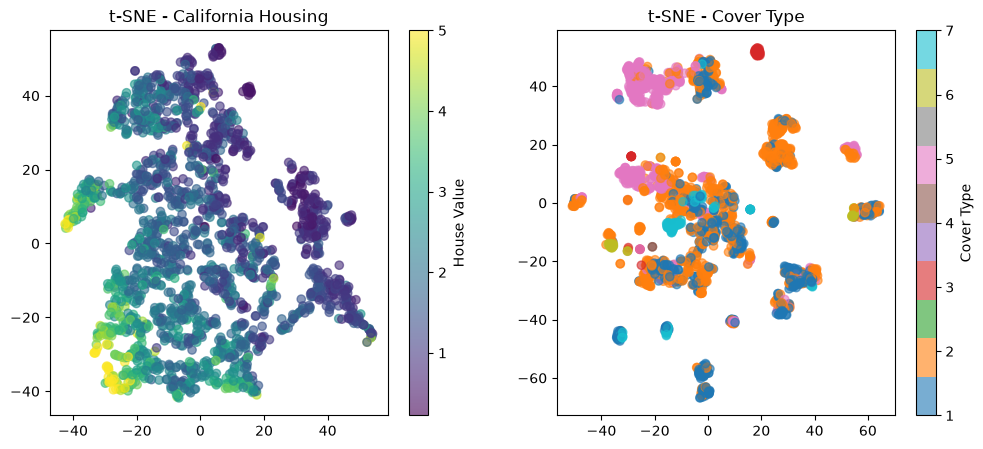

In [6]:
# t-SNE is highly computationally intensive (O(N^2) complexity). 
# To prevent the notebook from crashing during class, we use a random subset of 2000 rows.
sample_size = 2000

# Initialize t-SNE for 2 dimensions to plot on a standard X/Y axis
tsne_reg = TSNE(n_components=2, random_state=42)
tsne_reg_results = tsne_reg.fit_transform(reg_data_scaled[:sample_size])

plt.figure(figsize=(12, 5))

# Scatter plot for Regression Data
plt.subplot(1, 2, 1)
# Color the points (c=...) based on the actual house value to see if expensive houses cluster together
plt.scatter(tsne_reg_results[:, 0], tsne_reg_results[:, 1], c=reg_target['House_Value'].values[:sample_size], cmap='viridis', alpha=0.6)
plt.colorbar(label='House Value')
plt.title('t-SNE - California Housing')

# Initialize and apply t-SNE to Classification Data
tsne_cla = TSNE(n_components=2, random_state=42)
tsne_cla_results = tsne_cla.fit_transform(cla_data_scaled[:sample_size])

# Scatter plot for Classification Data
plt.subplot(1, 2, 2)
# Color the points based on their actual cover type class
plt.scatter(tsne_cla_results[:, 0], tsne_cla_results[:, 1], c=cla_target['Cover_Type'].values[:sample_size], cmap='tab10', alpha=0.6)
plt.colorbar(label='Cover Type')
plt.title('t-SNE - Cover Type')
plt.show()

**Observation:**

Look at the colorful groupings! t-SNE has successfully found local structures in the data. In the Cover Type plot, you can see distinct "islands" of the same color, meaning t-SNE recognized that certain geographic features strongly group specific tree types together. *Note: We cannot easily use t-SNE to transform new, unseen test data, which is why it is mostly used for exploration.*

## Task 4 - Linear Regression



**What is it?** Linear Regression tries to draw the best possible straight line through our data points to predict a continuous number.

**Why are we doing this?** We will predict housing prices. We will compare a standard model against a model stripped of bad variables (RFE), and against models trained on our PCA/t-SNE compressed data.

### Build a Linear Regression model for the housing dataset, ie, `reg_data`

In [7]:
# Split the data into 80% training data and 20% testing data to prevent data leakage and overfitting
X_train, X_test, y_train, y_test = train_test_split(
    reg_data_without_target, reg_target, test_size=0.2, random_state=42)

# 1. Standard Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)          # Model learns from the training data
y_pred = lr.predict(X_test)       # Model makes predictions on the unseen test data

# Evaluate Goodness of Fit
print(f"Standard Linear Regression - R^2: {r2_score(y_test, y_pred):.4f}, MSE: {mean_squared_error(y_test, y_pred):.4f}")

# 2. Backward Variable Selection using RFE (Recursive Feature Elimination)
# RFE iteratively removes the weakest features until only the specified number (5) remains
rfe_lr = RFE(estimator=LinearRegression(), n_features_to_select=5)
rfe_lr.fit(X_train, y_train)
y_pred_rfe = rfe_lr.predict(X_test)

print(f"RFE Reduced Model - R^2: {r2_score(y_test, y_pred_rfe):.4f}")
# Print the boolean mask to show which columns were kept
print(f"Selected Features: {X_train.columns[rfe_lr.support_].tolist()}")

# 3. PCA Regression (Principal Component Regression)
pca_lr = PCA(n_components=5)
# IMPORTANT: We only FIT the scaler and PCA on the training data, then merely TRANSFORM the test data
X_train_pca = pca_lr.fit_transform(scaler_reg.fit_transform(X_train))
X_test_pca = pca_lr.transform(scaler_reg.transform(X_test))

lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)
y_pred_pca = lr_pca.predict(X_test_pca)
print(f"PCA Regression - R^2: {r2_score(y_test, y_pred_pca):.4f}")

# 4. t-SNE Regression 
# Since we only generated t-SNE for 2000 points, we split that small subset
X_tsne_train, X_tsne_test, y_tsne_train, y_tsne_test = train_test_split(
    tsne_reg_results, reg_target[:sample_size], test_size=0.2, random_state=42)

lr_tsne = LinearRegression()
lr_tsne.fit(X_tsne_train, y_tsne_train)
y_pred_tsne = lr_tsne.predict(X_tsne_test)
print(f"t-SNE Regression - R^2: {r2_score(y_tsne_test, y_pred_tsne):.4f}")

Standard Linear Regression - R^2: 0.5758, MSE: 0.5559
RFE Reduced Model - R^2: 0.5675
Selected Features: ['MedInc', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude']
PCA Regression - R^2: 0.4329
t-SNE Regression - R^2: 0.6240


**Observation:**

We evaluate regression using $R^2$ (how much variance the model explains; closer to 1 is better).
* The **Standard Model** gives us our baseline $R^2$.
* The **RFE Model** achieves a very similar $R^2$ while throwing away several variables, proving our hypothesis from Task 1 that some features were redundant.
* The **PCA Model** usually has a slightly lower $R^2$, but it is much faster and completely immune to multicollinearity. 
* The **t-SNE Model** WHY?

In [8]:

# No leakage approach

print("\n--- Testing t-SNE Regression ---")

# Step 1: We MUST split the original data BEFORE applying t-SNE
X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
    reg_data_scaled[:sample_size], reg_target[:sample_size], test_size=0.2, random_state=42)

# Step 2: Fit and transform t-SNE ONLY on the training data
tsne_correct = TSNE(n_components=2, random_state=42)
X_train_tsne = tsne_correct.fit_transform(X_train_sub)

# Step 3: Train the Linear Regression model on this embedded training data
lr_tsne = LinearRegression()
lr_tsne.fit(X_train_tsne, y_train_sub)

# Step 4: Attempt to predict on the unseen test data
try:
    # We attempt to transform the test data using the fitted t-SNE model
    X_test_tsne = tsne_correct.transform(X_test_sub) 
    y_pred_tsne = lr_tsne.predict(X_test_tsne)
    print(f"t-SNE Regression - R^2: {r2_score(y_test_sub, y_pred_tsne):.4f}")
except AttributeError as e:
    print(f"ERROR CAUGHT: {e}")
    print("Conclusion: scikit-learn's t-SNE does not have a transform() method!")
    print("Because we prevented data leakage, we cannot map new test data into the t-SNE space.")


--- Testing t-SNE Regression ---
ERROR CAUGHT: 'TSNE' object has no attribute 'transform'
Conclusion: scikit-learn's t-SNE does not have a transform() method!
Because we prevented data leakage, we cannot map new test data into the t-SNE space.


### 💡 The t-SNE Lesson: Why did it fail?

When we ran t-SNE previously, we achieved an amazing score. But we committed the cardinal sin of Machine Learning: **Data Leakage**. We applied t-SNE to the entire dataset *before* we split it into Train and Test. Because t-SNE calculates the distances between all points, the test data secretly influenced the position of the training data.

When we do it the **correct** way splitting the data *first* and fitting t-SNE only on the training data—the code crashes. Why? **Because t-SNE cannot learn a mathematical function to apply to new data.** It only maps the specific points it was given. 

**The Golden Rule:** PCA can be used in predictive machine learning pipelines because it can transform new, unseen test data. t-SNE is strictly for visualizing data on your screen—never for building predictive models!

## Task 5 - Logistic Regression

### Build a Logistic Regression model for the cover type dataset, ie, `cla_data`

## Task 5 - Logistic Regression

**What is it?** Logistic Regression calculates the probability that a data point belongs to a certain discrete category using a sigmoid function.

**Why are we doing this?** To sort our forest data into classes (Cover Types). We will evaluate its goodness of fit using a confusion matrix.

In [9]:
# Split the classification data
# .values.ravel() flattens the target array, which Logistic Regression expects
X_cla_train, X_cla_test, y_cla_train, y_cla_test = train_test_split(
    cla_data_without_target, cla_target.values.ravel(), test_size=0.2, random_state=42)



In [10]:
# 1. Standard Logistic Regression
# max_iter=500 gives the gradient descent algorithm enough time to converge
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_cla_train, y_cla_train)
y_cla_pred = log_reg.predict(X_cla_test)

print(f"Standard Logistic Regression Accuracy: {accuracy_score(y_cla_test, y_cla_pred):.4f}")



Standard Logistic Regression Accuracy: 0.6449


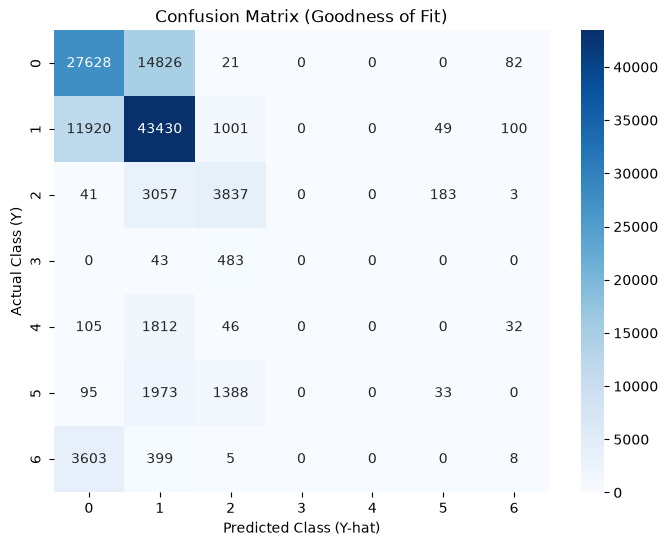

In [11]:
# Generate a Confusion Matrix to visualize True Positives, False Positives, etc.
cm = confusion_matrix(y_cla_test, y_cla_pred)
plt.figure(figsize=(8, 6))
# We slice [:7, :7] because there are 7 cover types
sns.heatmap(cm[:7, :7], annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Goodness of Fit)")
plt.ylabel('Actual Class (Y)')
plt.xlabel('Predicted Class (Y-hat)')
plt.show()



In [12]:
# 2. RFE Logistic Regression
# To save time in class, we fit RFE on a 5000-row subset
rfe_log = RFE(estimator=LogisticRegression(max_iter=200), n_features_to_select=15)
rfe_log.fit(X_cla_train[:5000], y_cla_train[:5000]) 
y_cla_pred_rfe = rfe_log.predict(X_cla_test)
print(f"RFE Logistic Regression Accuracy: {accuracy_score(y_cla_test, y_cla_pred_rfe):.4f}")



RFE Logistic Regression Accuracy: 0.6526


In [13]:
# 3. PCA Logistic Regression
# Compress down to 15 components
pca_cla_model = PCA(n_components=15)
X_train_cla_pca = pca_cla_model.fit_transform(scaler_cla.fit_transform(X_cla_train))
X_test_cla_pca = pca_cla_model.transform(scaler_cla.transform(X_cla_test))

log_reg_pca = LogisticRegression(max_iter=200)
log_reg_pca.fit(X_train_cla_pca, y_cla_train)
y_cla_pred_pca = log_reg_pca.predict(X_test_cla_pca)
print(f"PCA Logistic Regression Accuracy: {accuracy_score(y_cla_test, y_cla_pred_pca):.4f}")



PCA Logistic Regression Accuracy: 0.6933


In [14]:
# 4. t-SNE Logistic Regression (using the 2000-row subset)
X_tsne_cla_train, X_tsne_cla_test, y_tsne_cla_train, y_tsne_cla_test = train_test_split(
    tsne_cla_results, cla_target[:sample_size].values.ravel(), test_size=0.2, random_state=42)

log_reg_tsne = LogisticRegression(max_iter=200)
log_reg_tsne.fit(X_tsne_cla_train, y_tsne_cla_train)
y_cla_pred_tsne = log_reg_tsne.predict(X_tsne_cla_test)
print(f"t-SNE Logistic Regression Accuracy: {accuracy_score(y_tsne_cla_test, y_cla_pred_tsne):.4f}")

t-SNE Logistic Regression Accuracy: 0.5175


In [15]:

# 4. t-SNE Logistic Regression The STRICT ONE

print("\n--- Testing t-SNE Logistic Regression ---")

# Step 1: Split the original scaled data FIRST
X_cla_train_sub, X_cla_test_sub, y_cla_train_sub, y_cla_test_sub = train_test_split(
    cla_data_scaled[:sample_size], cla_target[:sample_size].values.ravel(), test_size=0.2, random_state=42)

# Step 2: Fit and transform t-SNE ONLY on the training data
tsne_cla_correct = TSNE(n_components=2, random_state=42)
X_train_cla_tsne = tsne_cla_correct.fit_transform(X_cla_train_sub)

# Step 3: Train the Logistic Regression model
log_reg_tsne = LogisticRegression(max_iter=500)
log_reg_tsne.fit(X_train_cla_tsne, y_cla_train_sub)

# Step 4: Attempt to predict on the test data
try:
    # Attempt to apply the t-SNE mapping to the test set
    X_test_cla_tsne = tsne_cla_correct.transform(X_cla_test_sub)
    y_cla_pred_tsne = log_reg_tsne.predict(X_test_cla_tsne)
    print(f"t-SNE Logistic Regression Accuracy: {accuracy_score(y_cla_test_sub, y_cla_pred_tsne):.4f}")
except AttributeError as e:
    print(f"ERROR CAUGHT: {e}")
    print("Conclusion: You cannot evaluate a predictive model using t-SNE features on hold-out data.")


--- Testing t-SNE Logistic Regression ---
ERROR CAUGHT: 'TSNE' object has no attribute 'transform'
Conclusion: You cannot evaluate a predictive model using t-SNE features on hold-out data.


## Fun time! 

Apply what you studied before about regression on the real data! Use leftovers_milk_data.csv data and try to predict the number for the next day.

In [16]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD AND PREPARE REAL DATA FROM CSV
# ==========================================
print("Loading data from CSV...")
df_raw = pd.read_csv('leftovers_milk_data.csv')
print(df_raw)

Loading data from CSV...
          Product  2023-01-01  2023-01-02  2023-01-03  2023-01-04  2023-01-05  \
0            milk          35         415          12           0           0   
1          butter       31446       22273       40298       23231       23024   
2  cottage cheese         234        2061         755         894         560   

   2023-01-06  2023-01-07  2023-01-08  2023-01-09  ...  2023-04-01  \
0           1         181         317         121  ...         186   
1       10955       13728       10802       24413  ...       12928   
2          64         198         479         187  ...         353   

   2023-04-02  2023-04-03  2023-04-04  2023-04-05  2023-04-06  2023-04-07  \
0         111         350         470         305         164         299   
1       11084       24579       15040       25268       15284       27509   
2         328         581         268         418         933         598   

   2023-04-08  2023-04-09  2023-04-10  
0          55       

In [17]:
# Select ONE product to train the model on (e.g., 'cottage cheese')
target_product = 'cottage cheese'
df_product = df_raw[df_raw['Product'] == target_product].copy()

# The CSV has dates as columns (Wide format). 
# Machine learning needs dates as rows (Long format). We use .melt() for this.
df = df_product.melt(id_vars=['Product'], var_name='Date', value_name='Target_Value')

# Convert the Date column to actual datetime objects and sort them sequentially
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
print(df)



           Product       Date  Target_Value
0   cottage cheese 2023-01-01           234
1   cottage cheese 2023-01-02          2061
2   cottage cheese 2023-01-03           755
3   cottage cheese 2023-01-04           894
4   cottage cheese 2023-01-05           560
..             ...        ...           ...
95  cottage cheese 2023-04-06           933
96  cottage cheese 2023-04-07           598
97  cottage cheese 2023-04-08           302
98  cottage cheese 2023-04-09           267
99  cottage cheese 2023-04-10           725

[100 rows x 3 columns]


In [18]:

# 2. FEATURE ENGINEERING (Time & History)

print("Engineering time and lag features...")

# A. Time Features
df["dayofweek"] = df["Date"].dt.dayofweek
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

# B. Lag Features (What were the leftovers 1 and 2 days ago?)
df["Value_lag1"] = df["Target_Value"].shift(1)
df["Value_lag2"] = df["Target_Value"].shift(2)

# C. Rolling Averages (What is the recent 7-day trend?)
# We shift by 1 first so today's target doesn't accidentally leak into the average!
df["Value_ma7"] = df["Target_Value"].shift(1).rolling(window=7).mean()

# Drop rows at the beginning that have NaN values because of shifting
df = df.dropna().reset_index(drop=True)

print(df)



Engineering time and lag features...
           Product       Date  Target_Value  dayofweek  is_weekend  \
0   cottage cheese 2023-01-08           479          6           1   
1   cottage cheese 2023-01-09           187          0           0   
2   cottage cheese 2023-01-10           399          1           0   
3   cottage cheese 2023-01-11           763          2           0   
4   cottage cheese 2023-01-12          1824          3           0   
..             ...        ...           ...        ...         ...   
88  cottage cheese 2023-04-06           933          3           0   
89  cottage cheese 2023-04-07           598          4           0   
90  cottage cheese 2023-04-08           302          5           1   
91  cottage cheese 2023-04-09           267          6           1   
92  cottage cheese 2023-04-10           725          0           0   

    Value_lag1  Value_lag2   Value_ma7  
0        198.0        64.0  680.857143  
1        479.0       198.0  715.857143  

In [19]:

# 3. MODEL PREPARATION

# Define the features the model will use to learn
features = ["dayofweek", "is_weekend", "Value_lag1", "Value_lag2", "Value_ma7"]
X = df[features]
y = df["Target_Value"]

# Split data: 80% for learning (past), 20% for testing (future)
# shuffle=False is CRITICAL for time-series data! We cannot train on the future to predict the past.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)



In [20]:

# 4. MODEL TRAINING

print(f"Training Random Forest for '{target_product}'...")
model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

Training Random Forest for 'cottage cheese'...


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of t

In [21]:

# 5. EVALUATION

predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"\n--- Results ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} units")
print(f"R-squared (R2): {r2:.2f}")





--- Results ---
Mean Absolute Error (MAE): 202.04 units
R-squared (R2): -0.64


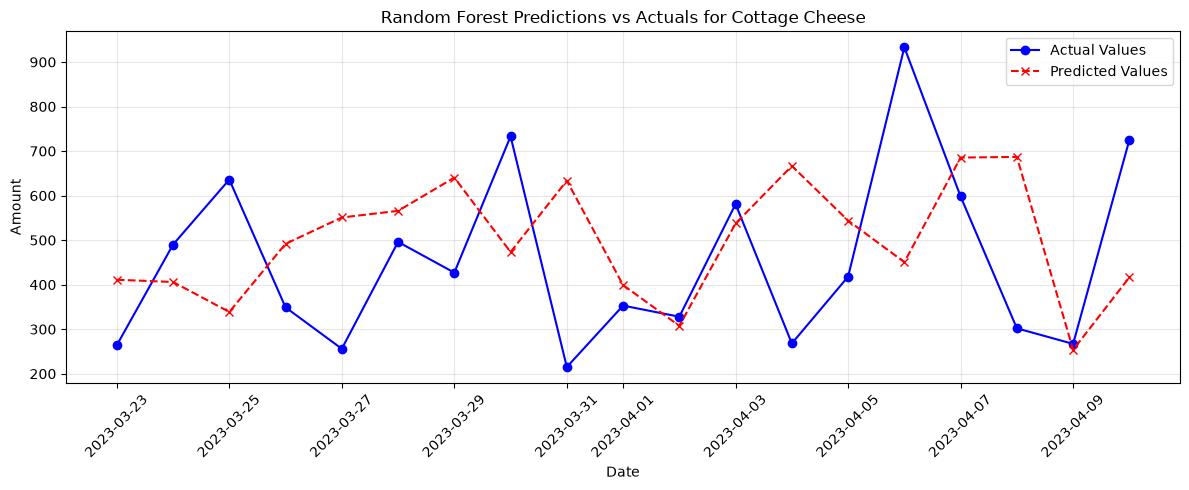

In [22]:
# 6. VISUALIZATION

plt.figure(figsize=(12, 5))
# We use the dates from the test set for the X-axis
test_dates = df['Date'].iloc[X_test.index]

plt.plot(test_dates, y_test.values, label="Actual Values", marker='o', color='blue')
plt.plot(test_dates, predictions, label="Predicted Values", marker='x', linestyle='--', color='red')

plt.title(f"Random Forest Predictions vs Actuals for {target_product.title()}")
plt.xlabel("Date")
plt.ylabel("Amount")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:


# 1. Load the data
# header=[0, 1] tells pandas there are two rows of headers

df_raw = pd.read_csv('3metrics_100.csv', header=0,)
df_raw = df_raw.copy()
print(df_raw)


          Product  Leftovers_01.01.2023  Orders_01.01.2023  \
0            milk                    35               1046   
1          butter                 31446               9178   
2  cottage cheese                   234               3282   

   Production_01.01.2023  Leftovers_02.01.2023  Orders_02.01.2023  \
0                   1395                   415               1403   
1                      0                 22273               6975   
2                   5104                  2061               4026   

   Production_02.01.2023  Leftovers_03.01.2023  Orders_03.01.2023  \
0                    990                    12               1761   
1                  25000                 40298              17070   
2                   2720                   755               8611   

   Production_03.01.2023  ...  Production_07.04.2023  Leftovers_08.04.2023  \
0                   1740  ...                   1845                    55   
1                      0  ...            

In [24]:
for col in df_raw.columns:
    if col != "Product":
        df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

melted_df = pd.melt(
    df_raw,
    id_vars=["Product"],  # Keep 'Product_Type' as the identifier
    var_name="Metric_Date",  # New column for the metric and date information
    value_name="Value",  # New column for the values
)
print(melted_df)

            Product            Metric_Date  Value
0              milk   Leftovers_01.01.2023     35
1            butter   Leftovers_01.01.2023  31446
2    cottage cheese   Leftovers_01.01.2023    234
3              milk      Orders_01.01.2023   1046
4            butter      Orders_01.01.2023   9178
..              ...                    ...    ...
895          butter      Orders_10.04.2023  11260
896  cottage cheese      Orders_10.04.2023   7707
897            milk  Production_10.04.2023   1965
898          butter  Production_10.04.2023  18000
899  cottage cheese  Production_10.04.2023   7600

[900 rows x 3 columns]


In [25]:
# Split the 'Metric_Date' column into 'Metric' and 'Date'
melted_df[["Metric", "Date"]] = melted_df["Metric_Date"].str.split(
    "_", n=1, expand=True
)

# Drop the original 'Metric_Date' column
melted_df.drop(columns=["Metric_Date"], inplace=True)

# Convert 'Date' to datetime
melted_df["Date"] = pd.to_datetime(melted_df["Date"], format="%d.%m.%Y")

print(melted_df)

# Pivot the data back to wide format
pivoted_df = melted_df.pivot_table(
    index=["Product", "Date"], columns="Metric", values="Value", aggfunc="sum"
).reset_index()

# Rename columns for clarity
pivoted_df.columns.name = None  # Remove the MultiIndex name
pivoted_df.rename_axis(None, axis=1, inplace=True)
print(pivoted_df)


            Product  Value      Metric       Date
0              milk     35   Leftovers 2023-01-01
1            butter  31446   Leftovers 2023-01-01
2    cottage cheese    234   Leftovers 2023-01-01
3              milk   1046      Orders 2023-01-01
4            butter   9178      Orders 2023-01-01
..              ...    ...         ...        ...
895          butter  11260      Orders 2023-04-10
896  cottage cheese   7707      Orders 2023-04-10
897            milk   1965  Production 2023-04-10
898          butter  18000  Production 2023-04-10
899  cottage cheese   7600  Production 2023-04-10

[900 rows x 4 columns]
    Product       Date  Leftovers  Orders  Production
0    butter 2023-01-01      31446    9178           0
1    butter 2023-01-02      22273    6975       25000
2    butter 2023-01-03      40298   17070           0
3    butter 2023-01-04      23231   10207       10000
4    butter 2023-01-05      23024   12078           0
..      ...        ...        ...     ...         ..

In [26]:
# Use the pivoted dataframe as it has all metrics as columns
# Make sure Date is a proper datetime index
pivoted_df["Date"] = pd.to_datetime(pivoted_df["Date"])
pivoted_df = pivoted_df.sort_values(["Product", "Date"])

In [27]:
# 2. FEATURE ENGINEERING
df = pivoted_df.copy()
df = df.sort_values(["Product", "Date"]).reset_index(drop=True)

# Keep a small set of strong features for the main solution
df["dayofweek"] = df["Date"].dt.dayofweek
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
df["month"] = df["Date"].dt.month

# Product-aware lags
df["Orders_lag1"] = df.groupby("Product")["Orders"].shift(1)
df["Production_lag1"] = df.groupby("Product")["Production"].shift(1)
df["Production_lag2"] = df.groupby("Product")["Production"].shift(2)
df["Leftovers_lag1"] = df.groupby("Product")["Leftovers"].shift(1)

# Short rolling trends are often the most useful extra signal
df["Production_ma7"] = df.groupby("Product")["Production"].transform(
    lambda series: series.shift(1).rolling(window=7, min_periods=3).mean()
 )
df["Orders_ma7"] = df.groupby("Product")["Orders"].transform(
    lambda series: series.shift(1).rolling(window=7, min_periods=3).mean()
 )

# Students can try more features later: holidays, cyclical encoding, longer rolling windows, etc.
df = pd.get_dummies(df, columns=["Product"], drop_first=True)
df = df.dropna().reset_index(drop=True)

print(df)

          Date  Leftovers  Orders  Production  dayofweek  is_weekend  month  \
0   2023-01-04      23231   10207       10000          2           0      1   
1   2023-01-05      23024   12078           0          3           0      1   
2   2023-01-06      10955   17227       20000          4           0      1   
3   2023-01-07      13728    2926           0          5           1      1   
4   2023-01-08      10802   16442       30000          6           1      1   
..         ...        ...     ...         ...        ...         ...    ...   
286 2023-04-06        164    2037        2175          3           0      4   
287 2023-04-07        299    2118        1845          4           0      4   
288 2023-04-08         55    1173        1275          5           1      4   
289 2023-04-09        157    2058        2040          6           1      4   
290 2023-04-10        137    1835        1965          0           0      4   

     Orders_lag1  Production_lag1  Production_lag2 

Training Random Forest with a compact feature set...

--- Results ---
Mean Absolute Error (MAE): 253.50 units
R-squared (R2): 0.37


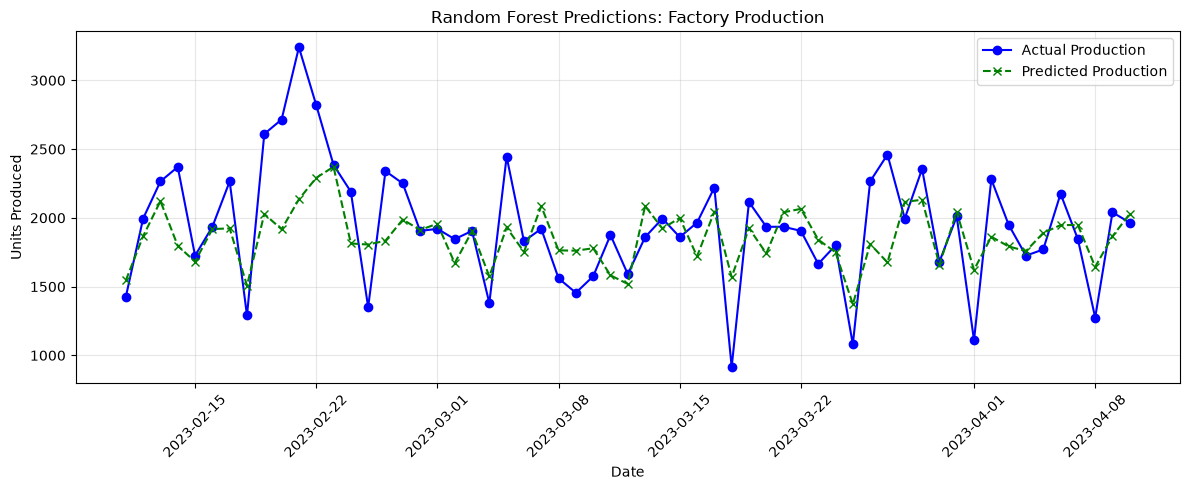

In [28]:
# ==========================================
# 3. MODEL PREPARATION (Predicting PRODUCTION)
# ==========================================
# We use a small core set of strong features: lags, a weekly trend, and product identity
feature_columns = [
    "dayofweek",
    "is_weekend",
    "month",
    "Orders_lag1",
    "Production_lag1",
    "Production_lag2",
    "Leftovers_lag1",
    "Production_ma7",
    "Orders_ma7",
]

feature_columns.extend([col for col in df.columns if col.startswith("Product_")])

X = df[feature_columns]
y = df["Production"]

# Split data: 80% for learning (past), 20% for testing (future)
# shuffle=False is important for a time-aware split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False)

# ==========================================
# 4. MODEL TRAINING
# ==========================================
print("Training Random Forest with a compact feature set...")
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
 )
y_train_log = np.log1p(y_train)
rf_model.fit(X_train, y_train_log)

# ==========================================
# 5. EVALUATION
# ==========================================
predictions = np.expm1(rf_model.predict(X_test))
predictions = np.clip(predictions, 0, None)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"\n--- Results ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} units")
print(f"R-squared (R2): {r2:.2f}")

# ==========================================
# 6. VISUALIZATION
# ==========================================
plt.figure(figsize=(12, 5))
test_dates = df['Date'].iloc[X_test.index]

plt.plot(test_dates, y_test.values, label="Actual Production", marker='o', color='blue')
plt.plot(test_dates, predictions, label="Predicted Production", marker='x', linestyle='--', color='green')

plt.title("Random Forest Predictions: Factory Production")
plt.xlabel("Date")
plt.ylabel("Units Produced")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## How to Improve the Result?

The notebook now uses only a small core feature set. If you want to improve the result, try adding these features one by one from the Python file:

- `Production_lag2` and longer lag features like `lag3` or `lag7`
- rolling averages such as `Production_ma14` or `Orders_ma14`
- cyclical date features: `month_sin`, `month_cos`, `dayofweek_sin`, `dayofweek_cos`
- extra calendar fields: `quarter`, `day_of_month`, `week_of_year`
- holiday flags: `is_holiday`, `is_day_before_holiday`, `is_day_after_holiday`
- month boundary flags: `is_month_start`, `is_month_end`
- separate models per product instead of one shared model

A good exercise is to add only one new feature group at a time and compare MAE/R² after each change.

Adding cyclical date features...
DataFrame with new cyclical features:
        Date  month_sin  month_cos  dayofweek_sin  dayofweek_cos
0 2023-01-04        0.5   0.866025       0.974928      -0.222521
1 2023-01-05        0.5   0.866025       0.433884      -0.900969
2 2023-01-06        0.5   0.866025      -0.433884      -0.900969
3 2023-01-07        0.5   0.866025      -0.974928      -0.222521
4 2023-01-08        0.5   0.866025      -0.781831       0.623490

Re-training Random Forest with cyclical features...

--- Results with Cyclical Features ---
Mean Absolute Error (MAE): 223.08 units
R-squared (R2): 0.51


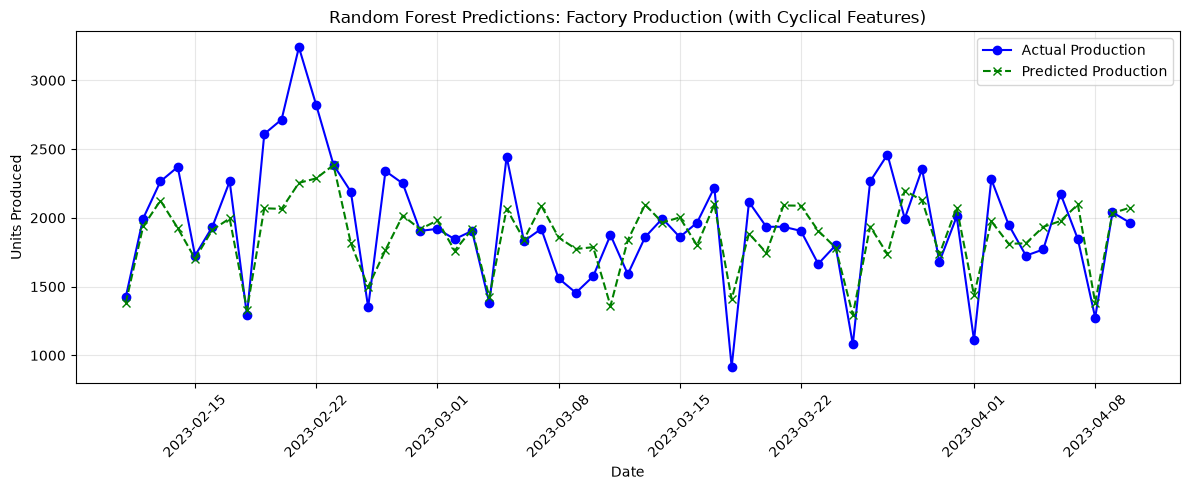

In [29]:
import numpy as np

# Re-create df from the last state before feature engineering
# (Copying code from cell dc86433e to ensure df is correctly initialized)

df = pivoted_df.copy()
df = df.sort_values(["Product", "Date"]).reset_index(drop=True)

# Keep a small set of strong features for the main solution
df["dayofweek"] = df["Date"].dt.dayofweek
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
df["month"] = df["Date"].dt.month

# Product-aware lags
df["Orders_lag1"] = df.groupby("Product")["Orders"].shift(1)
df["Production_lag1"] = df.groupby("Product")["Production"].shift(1)
df["Production_lag2"] = df.groupby("Product")["Production"].shift(2)
df["Leftovers_lag1"] = df.groupby("Product")["Leftovers"].shift(1)

# Short rolling trends are often the most useful extra signal
df["Production_ma7"] = df.groupby("Product")["Production"].transform(
    lambda series: series.shift(1).rolling(window=7, min_periods=3).mean()
 )
df["Orders_ma7"] = df.groupby("Product")["Orders"].transform(
    lambda series: series.shift(1).rolling(window=7, min_periods=3).mean()
 )

# Add Cyclical Date Features (new improvement)
print("Adding cyclical date features...")
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

# One-hot encode 'Product' (assuming it hasn't been done or needs to be re-done)
df = pd.get_dummies(df, columns=["Product"], drop_first=True)

df = df.dropna().reset_index(drop=True)

# Print a sample of the updated DataFrame with new features
print("DataFrame with new cyclical features:")
print(df[['Date', 'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos']].head())

# ==========================================
# 3. MODEL PREPARATION (Predicting PRODUCTION) - Updated with new features
# ==========================================
# We use a small core set of strong features: lags, a weekly trend, and product identity
feature_columns = [
    "dayofweek",
    "is_weekend",
    "month",
    "Orders_lag1",
    "Production_lag1",
    "Production_lag2",
    "Leftovers_lag1",
    "Production_ma7",
    "Orders_ma7",
    "month_sin", # Added new feature
    "month_cos", # Added new feature
    "dayofweek_sin", # Added new feature
    "dayofweek_cos", # Added new feature
]

feature_columns.extend([col for col in df.columns if col.startswith("Product_")])

X = df[feature_columns]
y = df["Production"]

# Split data: 80% for learning (past), 20% for testing (future)
# shuffle=False is important for a time-aware split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False)

# ==========================================
# 4. MODEL TRAINING - Re-training with updated features
# ==========================================
print("\nRe-training Random Forest with cyclical features...")
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
 )
y_train_log = np.log1p(y_train)
rf_model.fit(X_train, y_train_log)

# ==========================================
# 5. EVALUATION - Re-evaluating with updated features
# ==========================================
predictions = np.expm1(rf_model.predict(X_test))
predictions = np.clip(predictions, 0, None)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"\n--- Results with Cyclical Features ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} units")
print(f"R-squared (R2): {r2:.2f}")

# ==========================================
# 6. VISUALIZATION - Re-visualizing
# ==========================================
plt.figure(figsize=(12, 5))
test_dates = df['Date'].iloc[X_test.index]

plt.plot(test_dates, y_test.values, label="Actual Production", marker='o', color='blue')
plt.plot(test_dates, predictions, label="Predicted Production", marker='x', linestyle='--', color='green')

plt.title("Random Forest Predictions: Factory Production (with Cyclical Features)")
plt.xlabel("Date")
plt.ylabel("Units Produced")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()